# Предобраюотка данных

In [45]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import MinMaxScaler


In [46]:
# загрузка
df_air = pd.read_csv("../data/raw/eco_data/air-polution-data-2026-01-27.csv", sep=';', header=0)

df_air.columns

Index(['ID', 'Period', 'global_id', 'StationName',
       'SurveillanceZoneCharacteristics', 'AdmArea', 'District', 'Location',
       'Parameter', 'MonthlyAverage', 'MonthlyAveragePDKss', 'Unnamed: 11'],
      dtype='object')

In [47]:
df_air = df_air.drop(columns=['Unnamed: 11'])
df_air = df_air.drop(index=0)

df_air.head()

,ID,Period,global_id,StationName,SurveillanceZoneCharacteristics,AdmArea,District,Location,Parameter,MonthlyAverage,MonthlyAveragePDKss
1,1,02.2016,272777248,Лосиный остров,Природные территории,Восточный административный округ,район Метрогородок,"улица Ротерта, дом 4, строение 5",Оксид углерода,0.19,0.06
2,2,02.2016,272777249,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Оксид углерода,0.32,0.11
3,3,02.2016,272777250,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Сероводород,0.001,NaN
4,4,02.2016,272777251,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Оксид азота,0.014,0.23
5,5,02.2016,272777252,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Диоксид азота,0.024,0.59


In [48]:
df_air['MonthlyAveragePDKss'] = pd.to_numeric(df_air['MonthlyAveragePDKss'], errors='coerce')
df_air['MonthlyAverage'] = pd.to_numeric(df_air['MonthlyAverage'], errors='coerce')

In [49]:
# преобразуем Period в дату и выделяем год
df_air['Period'] = pd.to_datetime(df_air['Period'], format='%m.%Y').dt.to_period('M')
df_air['Year'] = df_air['Period'].dt.year

df_air.dtypes

ID                                    object
Period                             period[M]
global_id                             object
StationName                           object
SurveillanceZoneCharacteristics       object
AdmArea                               object
District                              object
Location                              object
Parameter                             object
MonthlyAverage                       float64
MonthlyAveragePDKss                  float64
Year                                   int64
dtype: object

## Справочная информация о загрязнении воздуха

In [50]:
df_pdk = pd.read_csv('../data/raw/eco_data/air-norms-data-2026-02-13.csv', sep=';', header = 0)
df_pdk = df_pdk.drop(columns=['Unnamed: 7'])
df_pdk = df_pdk.drop(index=0)

df_pdk.head()
df_pdk.dtypes

ID               object
ParameterName    object
global_id        object
UnitOfMeasure    object
PDKmr_ASIL       object
PDKss            object
DangerClass      object
dtype: object

In [51]:
df_pdk.dtypes

ID               object
ParameterName    object
global_id        object
UnitOfMeasure    object
PDKmr_ASIL       object
PDKss            object
DangerClass      object
dtype: object

In [52]:
# Преобразуем числовые колонки
for col in ['PDKmr_ASIL', 'PDKss']:
    df_pdk[col] = pd.to_numeric(df_pdk[col], errors='coerce')

# Преобразуем класс опасности в числовой
# Преобразуем в вес опасности: 1 класс = вес 1.0, 4 класс = вес 0.25
danger_weights = {
    '1': 1.0,   # чрезвычайно опасно
    '2': 0.7,   # высоко опасно  
    '3': 0.4,   # умеренно опасно
    '4': 0.2    # мало опасно
}
df_pdk['danger_weight'] = df_pdk['DangerClass'].map(danger_weights).fillna(0.1)

In [53]:
# Объединяем с основными данными
df_pdk = df_pdk.rename(columns={'ParameterName': 'Parameter'})
df_air = pd.merge(df_air, df_pdk[['Parameter', 'PDKss', 'PDKmr_ASIL', 'danger_weight']], on='Parameter', how='left')

df_air.head()

,ID,Period,global_id,StationName,SurveillanceZoneCharacteristics,AdmArea,District,Location,Parameter,MonthlyAverage,MonthlyAveragePDKss,Year,PDKss,PDKmr_ASIL,danger_weight
0,1,2016-02,272777248,Лосиный остров,Природные территории,Восточный административный округ,район Метрогородок,"улица Ротерта, дом 4, строение 5",Оксид углерода,0.190,0.06,2016,3.00,5.000,1.0
1,2,2016-02,272777249,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Оксид углерода,0.320,0.11,2016,3.00,5.000,1.0
2,3,2016-02,272777250,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Сероводород,0.001,NaN,2016,NaN,0.008,0.7
3,4,2016-02,272777251,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Оксид азота,0.014,0.23,2016,0.06,0.400,0.4
4,5,2016-02,272777252,Глебовская,Смешанные антропогенные источники загрязнений,Восточный административный округ,район Богородское,"Глебовская улица, дом 3, корпус 1",Диоксид азота,0.024,0.59,2016,0.10,0.200,0.4


In [54]:
df_air['weighted_pollution'] = df_air['MonthlyAveragePDKss'] * df_air['danger_weight']

station_aqi = (
    df_air.groupby(['StationName', 'District', 'Period', 'Year'])
    .agg(weighted_pollution_max=('weighted_pollution', 'max'),
        exceeds_count=('MonthlyAveragePDKss', lambda x: (x > 1).sum()))
    .rename(columns={'weighted_pollution_max': 'station_pollution'})
    .reset_index()
)

station_aqi.head()

,StationName,District,Period,Year,station_pollution,exceeds_count
0,Академика Анохина,район Тропарёво-Никулино,2013-01,2013,0.204,0
1,Академика Анохина,район Тропарёво-Никулино,2016-02,2016,0.320,0
2,Академика Анохина,район Тропарёво-Никулино,2016-03,2016,0.420,1
3,Академика Анохина,район Тропарёво-Никулино,2016-04,2016,0.368,0
4,Академика Анохина,район Тропарёво-Никулино,2016-05,2016,0.360,0


In [55]:
district_aqi = (
    station_aqi.groupby(['District', 'Period', 'Year'])
    .agg(station_pollution_mean=('station_pollution', 'mean'),
        exceeds_sum=('exceeds_count', 'sum'),
        stations_count=('StationName', 'count'))
    .rename(columns={'station_pollution_mean': 'station_pollution'})
    .reset_index()
)

district_aqi.head()

,District,Period,Year,station_pollution,exceeds_sum,stations_count
0,Академический район,2013-01,2013,0.130,0,1
1,Академический район,2016-02,2016,0.308,0,1
2,Академический район,2016-03,2016,0.428,1,1
3,Академический район,2016-04,2016,0.372,0,1
4,Академический район,2016-05,2016,0.376,0,1


In [56]:
# Максимальное возможное загрязнение ограничим 2 (2 ПДК)
district_aqi['pollution_clipped'] = district_aqi['station_pollution'].clip(0, 2)

# Преобразуем в индекс качества: чем выше pollution, тем ниже quality
district_aqi['air_quality_index'] = (1 - district_aqi['pollution_clipped'] / 2) * 100

In [57]:
def get_air_quality(score):
    if score >= 80:
        return 'Отлично'
    elif score >= 60:
        return 'Хорошо'
    elif score >= 40:
        return 'Удовлетворительно'
    elif score >= 20:
        return 'Плохо'
    else:
        return 'Опасно'

district_aqi['air_quality'] = district_aqi['air_quality_index'].apply(get_air_quality)

district_aqi.head(10)

,District,Period,Year,station_pollution,exceeds_sum,stations_count,pollution_clipped,air_quality_index,air_quality
0,Академический район,2013-01,2013,0.130,0,1,0.130,93.5,Отлично
1,Академический район,2016-02,2016,0.308,0,1,0.308,84.6,Отлично
2,Академический район,2016-03,2016,0.428,1,1,0.428,78.6,Хорошо
3,Академический район,2016-04,2016,0.372,0,1,0.372,81.4,Отлично
4,Академический район,2016-05,2016,0.376,0,1,0.376,81.2,Отлично
5,Академический район,2016-06,2016,0.284,0,1,0.284,85.8,Отлично
6,Академический район,2016-07,2016,0.360,0,1,0.360,82.0,Отлично
7,Академический район,2016-08,2016,0.340,0,1,0.340,83.0,Отлично
8,Академический район,2016-09,2016,0.280,0,1,0.280,86.0,Отлично
9,Академический район,2016-10,2016,0.344,0,1,0.344,82.8,Отлично


In [58]:
district_2025 = district_aqi[district_aqi['Year'] == 2025].copy()

district_2025.head()

,District,Period,Year,station_pollution,exceeds_sum,stations_count,pollution_clipped,air_quality_index,air_quality
106,Академический район,2025-02,2025,0.212,0,1,0.212,89.4,Отлично
107,Академический район,2025-03,2025,0.204,0,1,0.204,89.8,Отлично
108,Академический район,2025-04,2025,0.070,0,1,0.070,96.5,Отлично
109,Академический район,2025-05,2025,0.070,0,1,0.070,96.5,Отлично
110,Академический район,2025-06,2025,0.080,0,1,0.080,96.0,Отлично


In [59]:
district_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 106 to 4934
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   District           506 non-null    object   
 1   Period             506 non-null    period[M]
 2   Year               506 non-null    int64    
 3   station_pollution  505 non-null    float64  
 4   exceeds_sum        506 non-null    int64    
 5   stations_count     506 non-null    int64    
 6   pollution_clipped  505 non-null    float64  
 7   air_quality_index  505 non-null    float64  
 8   air_quality        506 non-null    object   
dtypes: float64(3), int64(3), object(2), period[M](1)
memory usage: 39.5+ KB


In [60]:
# АГРЕГАЦИЯ ПО РАЙОНУ ЗА 2025 ГОД
district_2025_annual = (
    district_2025.groupby('District')
    .agg(air_quality_score=('air_quality_index', 'mean'),
        station_pollution=('station_pollution', 'mean'),
        exceeds_sum=('exceeds_sum', 'sum'),
        stations_count=('stations_count', 'mean'),
        months_available=('Period', 'count'))
    .reset_index()
)

district_2025_annual['air_quality_score'] = district_2025_annual['air_quality_score'].round(1)
district_2025_annual['air_quality'] = district_2025_annual['air_quality_score'].apply(get_air_quality)

district_2025_annual.head(10)

,District,air_quality_score,station_pollution,exceeds_sum,stations_count,months_available,air_quality
0,Академический район,94.7,0.105273,0,1.0,11,Отлично
1,Басманный район,92.6,0.147667,0,1.0,12,Отлично
2,Даниловский район,87.8,0.244545,0,1.0,11,Отлично
3,Дмитровский район,92.4,0.152000,0,1.0,12,Отлично
4,Донской район,88.3,0.234091,0,2.0,11,Отлично
5,Мещанский район,90.7,0.185833,0,1.0,12,Отлично
6,Можайский район,94.8,0.103500,0,1.0,12,Отлично
7,Останкинский район,93.6,0.128000,0,1.0,12,Отлично
8,Пресненский район,92.9,0.142000,0,1.0,12,Отлично
9,Рязанский район,91.5,0.170667,0,1.0,12,Отлично


## Шум

In [61]:
df_noise = pd.read_csv('../data/raw/eco_data/noise-data-2026-01-22.csv', sep=';', header=0)
df_noise = df_noise.drop(index=0)

df_noise.head()

,ID,Date,global_id,AdmArea,District,Longitude_WGS84,Latitude_WGS84,Location,TerritoryType,NoiseCategory,Results,geoData,geodata_center,Unnamed: 13
1,982,06.09.2016,279137532,Южный административный округ,Даниловский район,37.634479,55.708770,"Даниловская набережная, дом 2, корпус 1","Территория, прилегающая к жилым домам первой л...",Строительные работы,Выявлены превышения нормативов допустимого уро...,"{coordinates=[37.634479, 55.70877], type=Point}","{coordinates=[37.634479, 55.70877], type=Point}",NaN
2,1000,07.09.2016,279137533,Юго-Восточный административный округ,район Некрасовка,37.927329,55.708658,"Сочинская улица, дом 2","Территория, прилегающая к жилым домам первой л...",Автотранспорт,Выявлены превышения нормативов допустимого уро...,"{coordinates=[37.927329, 55.708658], type=Point}","{coordinates=[37.927329, 55.708658], type=Point}",NaN
3,1001,08.09.2016,279137534,Юго-Восточный административный округ,район Люблино,37.751071,55.687259,"Краснодонская улица, дом 2, корпус 3","Территория, прилегающая к жилым домам за перво...","[Кафе, ресторан, клуб, Музыка]",Превышения нормативов допустимого уровня шума ...,"{coordinates=[37.751071, 55.687259], type=Point}","{coordinates=[37.751071, 55.687259], type=Point}",NaN
4,1002,09.09.2016,279137535,Юго-Восточный административный округ,район Текстильщики,37.737426,55.705239,"8-я улица Текстильщиков, дом 2, корпус 1","Территория, прилегающая к жилым домам первой л...",Генераторная установка,Выявлены превышения нормативов допустимого уро...,"{coordinates=[37.737426, 55.705239], type=Point}","{coordinates=[37.737426, 55.705239], type=Point}",NaN
5,1003,09.09.2016,279137536,Юго-Восточный административный округ,район Лефортово,37.680670,55.755616,"Волочаевская улица, дом 14, корпус 1","Территория, прилегающая к жилым домам за перво...",Вентиляционные системы,Выявлены превышения нормативов допустимого уро...,"{coordinates=[37.68067, 55.755616], type=Point}","{coordinates=[37.68067, 55.755616], type=Point}",NaN


In [62]:
df_noise['Results'].unique()

array(['Выявлены превышения нормативов допустимого уровня шума от автотранспорта.',
       'Превышения нормативов допустимого уровня шума от работы летнего кафе не выявлены, выявлены превышения нормативов допустимого уровня шума от автотранспорта.',
       'Выявлены превышения нормативов допустимого уровня шума от работы вентиляционного оборудования.',
       'Превышения нормативов допустимого уровня шума от работы автомойки не выявлены, выявлены превышения нормативов допустимого уровня шума от автотранспорта.',
       'Превышения нормативов допустимого уровня шума не выявлены.',
       'Выявлены превышения нормативов допустимого уровня шума от совместного влияния промышленного предприятия и автотранспорта.',
       'Превышения нормативов допустимого уровня шума от погрузочно-разгрузочных работ не выявлены, выявлены превышения нормативов допустимого уровня шума от автотранспорта.',
       'Выявлены превышения нормативов допустимого уровня шума от строительных работ.',
       'На момент

In [63]:
df_noise.dtypes

ID                  object
Date                object
global_id           object
AdmArea             object
District            object
Longitude_WGS84     object
Latitude_WGS84      object
Location            object
TerritoryType       object
NoiseCategory       object
Results             object
geoData             object
geodata_center      object
Unnamed: 13        float64
dtype: object

In [64]:
df_noise['Date'] = pd.to_datetime(
    df_noise['Date'],
    format='%d.%m.%Y',
    errors='coerce'
)

df_noise['Year'] = df_noise['Date'].dt.year

In [65]:
# фильтр по годам
df_noise = df_noise[df_noise['Year'].between(2024, 2026)]

In [66]:
df_noise['noise_exceed'] = df_noise['Results'].str.startswith(
    'Выявлены',
    na=False
)

In [67]:
noise_stats = (
    df_noise.groupby(['District', 'Year'])
    .agg(total_events=('ID', 'count'),
        exceed_events=('noise_exceed', 'sum'))
    .reset_index()
)

# доля превышений
noise_stats['exceed_share'] = noise_stats['exceed_events'] / noise_stats['total_events']

noise_stats.head()

,District,Year,total_events,exceed_events,exceed_share
0,Академический район,2024,8,2,0.250000
1,Академический район,2025,10,3,0.300000
2,Алексеевский район,2024,7,2,0.285714
3,Алексеевский район,2025,12,3,0.250000
4,Алтуфьевский район,2024,3,1,0.333333


In [68]:
# ВЫБИРАЕМ ШУМОВЫЕ ДАННЫЕ ЗА 2025
noise_2025 = noise_stats[noise_stats['Year'] == 2025].copy()

# Создаем "шумовой индекс" (чем выше - тем хуже)
# exceed_share - это доля превышений от всех замеров
noise_2025['noise_quality'] = 100 - (noise_2025['exceed_share'] * 100)

# Категория шумового загрязнения
def noise_category(score):
    if score >= 90:
        return 'Тихо'
    elif score >= 70:
        return 'Умеренно'
    elif score >= 50:
        return 'Шумно'
    else:
        return 'Очень шумно'

noise_2025['noise_level'] = noise_2025['noise_quality'].apply(noise_category)

noise_2025[['District', 'total_events', 'exceed_share', 'noise_quality', 'noise_level']].head(10)
print(f"\nВсего районов в шумовых данных: {len(noise_2025)}")


Всего районов в шумовых данных: 121


## Объединение данных о загрязнении воздуха и о шуме

In [69]:
# Переименуем колонки для ясности
air_quality = district_2025_annual.rename(columns={
    'air_quality_score': 'air_quality_score',
    'air_quality': 'air_quality_category'
})

# Объединяем по району
ecology_2025 = pd.merge(air_quality, noise_2025[['District', 'noise_quality', 'noise_level', 'exceed_share']], 
                        on='District', how='left')

# Заполняем пропуски (если для района нет шумовых данных)
ecology_2025['noise_quality'] = ecology_2025['noise_quality'].fillna(100)  # нет данных = тихо
ecology_2025['noise_level'] = ecology_2025['noise_level'].fillna('Нет данных')
ecology_2025['exceed_share'] = ecology_2025['exceed_share'].fillna(0)

print("Объединенные данные:")
ecology_2025[['District', 'air_quality_score', 'air_quality_category', 
            'noise_quality', 'noise_level', 'exceed_share']].head(10)

Объединенные данные:


,District,air_quality_score,air_quality_category,noise_quality,noise_level,exceed_share
0,Академический район,94.7,Отлично,70.000000,Умеренно,0.300000
1,Басманный район,92.6,Отлично,77.272727,Умеренно,0.227273
2,Даниловский район,87.8,Отлично,69.444444,Шумно,0.305556
3,Дмитровский район,92.4,Отлично,83.333333,Умеренно,0.166667
4,Донской район,88.3,Отлично,82.608696,Умеренно,0.173913
5,Мещанский район,90.7,Отлично,100.000000,Тихо,0.000000
6,Можайский район,94.8,Отлично,72.727273,Умеренно,0.272727
7,Останкинский район,93.6,Отлично,100.000000,Тихо,0.000000
8,Пресненский район,92.9,Отлично,73.684211,Умеренно,0.263158
9,Рязанский район,91.5,Отлично,78.947368,Умеренно,0.210526


In [70]:
# --- НОРМИРОВКА ПОКАЗАТЕЛЕЙ (0-100, где 100 - лучший) ---
# У нас оба показателя уже в шкале 0-100, где 100 - хорошо

# Но нужно убедиться, что шкалы сопоставимы
# air_quality_score: 85-96 (все хорошо)
# noise_quality: 0-100 (большой разброс)

# Нормируем оба показателя к единой шкале 0-100
scaler = MinMaxScaler(feature_range=(0, 100))
ecology_2025['air_normalized'] = scaler.fit_transform(ecology_2025[['air_quality_score']])
ecology_2025['noise_normalized'] = scaler.fit_transform(ecology_2025[['noise_quality']])

# --- СОЗДАЕМ ИНТЕГРАЛЬНЫЙ ИНДЕКС ---
# Веса можно настроить
AIR_WEIGHT = 0.6
NOISE_WEIGHT = 0.4

ecology_2025['eco_index'] = (ecology_2025['air_normalized'] * AIR_WEIGHT + 
                              ecology_2025['noise_normalized'] * NOISE_WEIGHT)

# --- КАТЕГОРИИ ЭКОЛОГИЧНОСТИ ---
def eco_category(score):
    if score >= 80:
        return 'A (Отлично)'
    elif score >= 60:
        return 'B (Хорошо)'
    elif score >= 40:
        return 'C (Удовлетворительно)'
    elif score >= 20:
        return 'D (Плохо)'
    else:
        return 'E (Опасно)'

ecology_2025['eco_category'] = ecology_2025['eco_index'].apply(eco_category)

print("\nИнтегральная экологическая оценка:")
ecology_2025[['District', 'air_quality_score', 'noise_quality', 
            'eco_index', 'eco_category']].head(15)


Интегральная экологическая оценка:


,District,air_quality_score,noise_quality,eco_index,eco_category
0,Академический район,94.7,70.000000,79.743119,B (Хорошо)
1,Басманный район,92.6,77.272727,71.092577,B (Хорошо)
2,Даниловский район,87.8,69.444444,41.539246,C (Удовлетворительно)
3,Дмитровский район,92.4,83.333333,72.415902,B (Хорошо)
4,Донской район,88.3,82.608696,49.557240,C (Удовлетворительно)
5,Мещанский район,90.7,100.000000,69.724771,B (Хорошо)
6,Можайский район,94.8,72.727273,81.384487,A (Отлично)
7,Останкинский район,93.6,100.000000,85.688073,A (Отлично)
8,Пресненский район,92.9,73.684211,71.308547,B (Хорошо)
9,Рязанский район,91.5,78.947368,65.707388,B (Хорошо)


In [71]:
# ПОДГОТАВЛИВАЕМ ФИНАЛЬНЫЙ ДАТАСЕТ
ecology_final = ecology_2025[['District', 'air_quality_score', 'air_quality_category',
                            'noise_quality', 'noise_level', 'exceed_share',
                            'eco_index', 'eco_category']].copy()

# Округляем для читаемости
ecology_final['air_quality_score'] = ecology_final['air_quality_score'].round(1)
ecology_final['noise_quality'] = ecology_final['noise_quality'].round(1)
ecology_final['eco_index'] = ecology_final['eco_index'].round(1)

ecology_final.head(10)

# Сохраняем
ecology_final.to_csv('ecology_by_district_2025.csv', index=False, encoding='utf-8-sig')
print("\nФайл сохранен: ecology_by_district_2025.csv")


Файл сохранен: ecology_by_district_2025.csv


## Объединение с данными о недвижимости

In [72]:
df_realty = pd.read_csv('../data/avito_csv/realty_data.csv')

df_realty.head()

print(f"Загружено объявлений: {len(df_realty)}")
print(f"Уникальных районов: {df_realty['district'].nunique()}")
print(f"Диапазон цен: {df_realty['price_per_sqm'].min():,.0f} - {df_realty['price_per_sqm'].max():,.0f} ₽/м²")

Загружено объявлений: 3182
Уникальных районов: 41
Диапазон цен: 0 - 6,027,397 ₽/м²


In [73]:
df_realty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   district       3182 non-null   object 
 1   property_type  3182 non-null   object 
 2   price_total    3182 non-null   int64  
 3   area           3182 non-null   float64
 4   price_per_sqm  3182 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 124.4+ KB


In [74]:
# Агрегация по районам
df_realty_agg = df_realty.groupby('district').agg({
    'price_per_sqm': 'mean',
    'price_total': 'mean',
    'area': 'mean'
}).reset_index()

# Добавляем количество объявлений
ads_count = df_realty.groupby('district').size().reset_index(name='ads_count')
df_realty_agg = df_realty_agg.merge(ads_count, on='district', how='left')

# Добавляем медианную цену
price_median = df_realty.groupby('district')['price_per_sqm'].median().reset_index(name='price_per_sqm_median')
df_realty_agg = df_realty_agg.merge(price_median, on='district', how='left')

In [75]:
# Переименовываем для соответствия
df_realty_agg.rename(columns={
    'district': 'District',
    'price_per_sqm': 'price_per_sqm_mean',
    'price_total': 'price_total_mean',
    'area': 'area_mean'
}, inplace=True)

# Форматирование
df_realty_agg['price_per_sqm_mean'] = df_realty_agg['price_per_sqm_mean'].round(0).astype(int)
df_realty_agg['price_per_sqm_median'] = df_realty_agg['price_per_sqm_median'].round(0).astype(int)
df_realty_agg['price_per_sqm_formatted'] = df_realty_agg['price_per_sqm_mean'].apply(
    lambda x: f"{x:,.0f} ₽/м²"
)

print("Агрегированные данные по недвижимости:")
df_realty_agg.head()

Агрегированные данные по недвижимости:


,District,price_per_sqm_mean,price_total_mean,area_mean,ads_count,price_per_sqm_median,price_per_sqm_formatted
0,Академический,480765,3.284102e+07,61.165000,60,433534,"480,765 ₽/м²"
1,Алексеевский,456321,2.964614e+07,63.275000,120,436493,"456,321 ₽/м²"
2,Алтуфьевский,347655,1.589188e+07,45.883333,60,351458,"347,655 ₽/м²"
3,Арбат,1475988,2.288024e+08,124.395000,60,1020964,"1,475,988 ₽/м²"
4,Аэропорт,499818,2.943446e+07,57.503333,60,450000,"499,818 ₽/м²"


In [76]:
# Проверяем информацию
print(f"\nВсего районов в данных о недвижимости: {len(df_realty_agg)}")
print(f"Диапазон цен за кв.м: от {df_realty_agg['price_per_sqm_mean'].min():,} до {df_realty_agg['price_per_sqm_mean'].max():,} ₽")


Всего районов в данных о недвижимости: 41
Диапазон цен за кв.м: от 253,507 до 1,528,527 ₽


In [77]:
print("Уникальные названия районов в экологии (первые 10):")
print(ecology_final['District'].head(10))
print("\nУникальные названия районов в недвижимости (первые 10):")
print(df_realty_agg['District'].head(10))

Уникальные названия районов в экологии (первые 10):
0    Академический район
1        Басманный район
2      Даниловский район
3      Дмитровский район
4          Донской район
5        Мещанский район
6        Можайский район
7     Останкинский район
8      Пресненский район
9        Рязанский район
Name: District, dtype: object

Уникальные названия районов в недвижимости (первые 10):
0        Академический
1         Алексеевский
2         Алтуфьевский
3                Арбат
4             Аэропорт
5            Басманный
6    Бирюлёво Западное
7          Богородское
8          Даниловский
9          Дмитровский
Name: District, dtype: object


In [78]:
# ФУНКЦИЯ ДЛЯ НОРМАЛИЗАЦИИ НАЗВАНИЙ
def normalize_district_name(name):
    if pd.isna(name):
        return name
    name = str(name)
    name = re.sub(r'\s+район$', '', name, flags=re.IGNORECASE)
    name = re.sub(r'^район\s+', '', name, flags=re.IGNORECASE)
    return ' '.join(name.split())

# НОРМАЛИЗУЕМ НАЗВАНИЯ 
ecology_final['District_norm'] = ecology_final['District'].apply(normalize_district_name)
df_realty_agg['District_norm'] = df_realty_agg['District'].apply(normalize_district_name)

In [79]:
# Объединение (только районы с эко-данными)
eco_subset = ecology_final[['District_norm', 'eco_index', 'eco_category', 
                            'air_quality_score', 'noise_quality']].copy()

df_merged = pd.merge(df_realty_agg, eco_subset, left_on='District_norm', 
                    right_on='District_norm', how='inner')

df_merged = df_merged.drop(columns=['District_norm'])

In [80]:
# Финальный датасет
df_final = df_merged[['District', 'price_per_sqm_mean', 'price_per_sqm_median', 
                    'price_per_sqm_formatted', 'area_mean', 'ads_count',
                    'eco_index', 'eco_category', 'air_quality_score', 'noise_quality']].copy()

df_final.to_csv('../data/processed/realty_with_ecology_full.csv', index=False)

print(f"\n✅ Сохранено {len(df_final)} районов")

# Простая статистика
print("\n" + "="*80)
print("СТАТИСТИКА ПО ОБЪЕДИНЕННОМУ ДАТАСЕТУ:")
print("="*80)
print(f"Всего районов: {len(df_final)}")
print(f"Районов с экоданными: {(df_final['eco_category'] != 'Нет данных').sum()}")
print(f"Диапазон цен: от {df_final['price_per_sqm_mean'].min():,.0f} до {df_final['price_per_sqm_mean'].max():,.0f} ₽/м²")
print(f"Средняя цена: {df_final['price_per_sqm_mean'].mean():,.0f} ₽/м²")
print(f"Медианная цена: {df_final['price_per_sqm_mean'].median():,.0f} ₽/м²")


✅ Сохранено 38 районов

СТАТИСТИКА ПО ОБЪЕДИНЕННОМУ ДАТАСЕТУ:
Всего районов: 38
Районов с экоданными: 38
Диапазон цен: от 253,507 до 1,528,527 ₽/м²
Средняя цена: 505,292 ₽/м²
Медианная цена: 429,060 ₽/м²


In [81]:
df_final.head()

,District,price_per_sqm_mean,price_per_sqm_median,price_per_sqm_formatted,area_mean,ads_count,eco_index,eco_category,air_quality_score,noise_quality
0,Академический,480765,433534,"480,765 ₽/м²",61.165000,60,79.7,B (Хорошо),94.7,70.0
1,Аэропорт,499818,450000,"499,818 ₽/м²",57.503333,60,56.4,C (Удовлетворительно),89.9,77.8
2,Басманный,532194,499768,"532,194 ₽/м²",57.721667,120,71.1,B (Хорошо),92.6,77.3
3,Бирюлёво Западное,253507,264767,"253,507 ₽/м²",48.412000,100,60.8,B (Хорошо),91.5,66.7
4,Богородское,391576,367542,"391,576 ₽/м²",59.363333,60,77.0,B (Хорошо),93.3,82.4


## Аналитика

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [83]:
df_final = pd.read_csv('../data/processed/realty_with_ecology_full.csv')

In [84]:
# Статистический анализ корреляции
r_mean, p_mean = stats.pearsonr(df_final['price_per_sqm_mean'], df_final['eco_index'])
r2_mean = r_mean ** 2

r_median, p_median = stats.pearsonr(df_final['price_per_sqm_median'], df_final['eco_index'])
r2_median = r_median ** 2

def interpret_correlation(r):
    abs_r = abs(r)
    if abs_r < 0.1:
        return 'очень слабая'
    elif abs_r < 0.3:
        return 'слабая'
    elif abs_r < 0.5:
        return 'умеренная'
    elif abs_r < 0.7:
        return 'заметная'
    elif abs_r < 0.9:
        return 'высокая'
    else:
        return 'очень высокая'

direction = 'положительная' if r_mean > 0 else 'отрицательная'
strength = interpret_correlation(r_mean)

print("=" * 60)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("=" * 60)
print(f"Количество районов в анализе: {len(df_final)}")
print(f"\nКорреляция Пирсона (средняя цена vs эко-индекс):")
print(f"  r = {r_mean:.4f}")
print(f"  p-value = {p_mean:.6f}")
print(f"  R² = {r2_mean:.4f}")
print(f"  Интерпретация: {strength} {direction} связь")
print(f"  Статистическая значимость: {'значимо' if p_mean < 0.05 else 'не значимо'}")
print(f"\nКорреляция Пирсона (медианная цена vs эко-индекс):")
print(f"  r = {r_median:.4f}")
print(f"  p-value = {p_median:.6f}")
print(f"  R² = {r2_median:.4f}")

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
Количество районов в анализе: 38

Корреляция Пирсона (средняя цена vs эко-индекс):
  r = 0.1175
  p-value = 0.482472
  R² = 0.0138
  Интерпретация: слабая положительная связь
  Статистическая значимость: не значимо

Корреляция Пирсона (медианная цена vs эко-индекс):
  r = 0.0147
  p-value = 0.930422
  R² = 0.0002


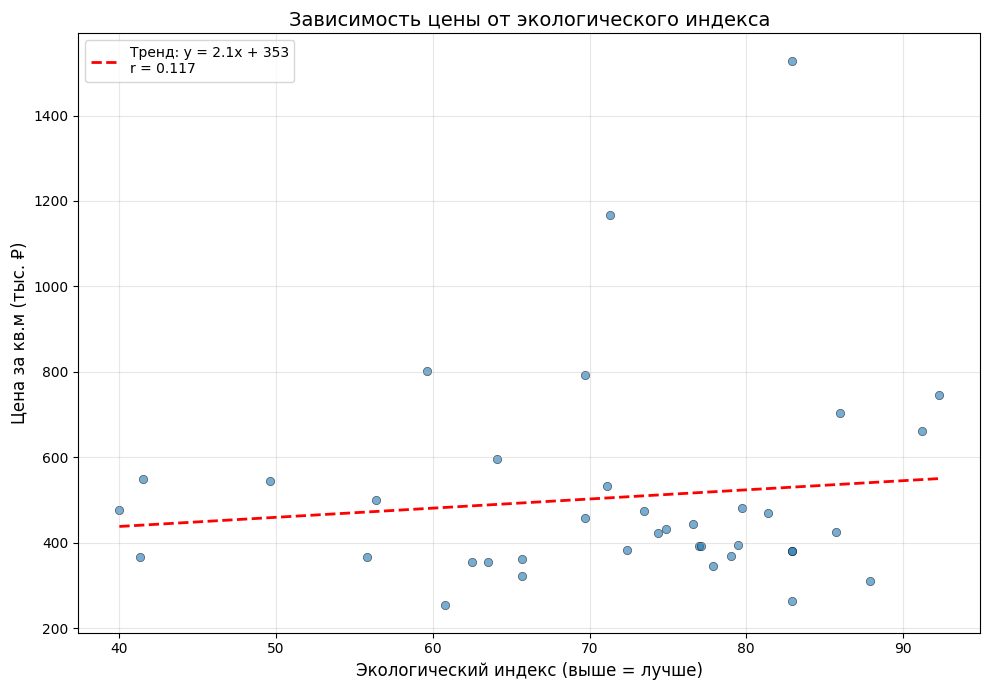

In [85]:
# Диаграмма рассеяния: цена vs экологический индекс
fig, ax = plt.subplots(figsize=(10, 7))

x = df_final['eco_index']
y = df_final['price_per_sqm_mean'] / 1000

ax.scatter(x, y, alpha=0.6, edgecolors='black', linewidth=0.5)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_trend = np.linspace(x.min(), x.max(), 100)
ax.plot(x_trend, p(x_trend), 'r--', linewidth=2,
        label=f'Тренд: y = {z[0]:.1f}x + {z[1]:.0f}\nr = {r_mean:.3f}')

ax.set_xlabel('Экологический индекс (выше = лучше)', fontsize=12)
ax.set_ylabel('Цена за кв.м (тыс. ₽)', fontsize=12)
ax.set_title('Зависимость цены от экологического индекса', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

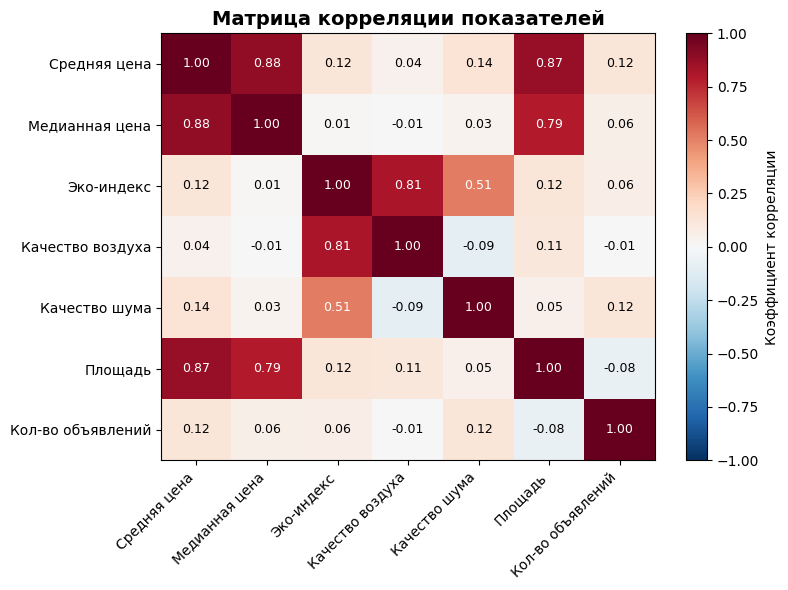

In [86]:
# Тепловая карта: матрица корреляций
metrics = ['price_per_sqm_mean', 'price_per_sqm_median', 'eco_index', 
        'air_quality_score', 'noise_quality', 'area_mean', 'ads_count']

available_metrics = [m for m in metrics if m in df_final.columns]
labels = ['Средняя цена', 'Медианная цена', 'Эко-индекс', 
        'Качество воздуха', 'Качество шума', 'Площадь', 'Кол-во объявлений'][:len(available_metrics)]

corr_matrix = df_final[available_metrics].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Матрица корреляции показателей', fontsize=14, fontweight='bold')

for i in range(len(labels)):
        for j in range(len(labels)):
                text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                        ha='center', va='center',
                        color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black',
                        fontsize=9)

plt.colorbar(im, ax=ax, label='Коэффициент корреляции')
plt.tight_layout()
plt.show()

In [87]:
# Топ-5 самых дорогих районов
print("=" * 60)
print("ТОП-5 САМЫХ ДОРОГИХ РАЙОНОВ")
print("=" * 60)
top_price = df_final.nlargest(5, 'price_per_sqm_mean')
for i, (idx, row) in enumerate(top_price.iterrows(), 1):
    print(f"{i}. {row['District']}")
    print(f"   Цена: {row['price_per_sqm_formatted']}")
    print(f"   Эко-индекс: {row['eco_index']:.1f}")
    print()

# Топ-5 самых экологичных районов
print("=" * 60)
print("ТОП-5 САМЫХ ЭКОЛОГИЧНЫХ РАЙОНОВ")
print("=" * 60)
top_eco = df_final.nlargest(5, 'eco_index')
for i, (idx, row) in enumerate(top_eco.iterrows(), 1):
    print(f"{i}. {row['District']}")
    print(f"   Эко-индекс: {row['eco_index']:.1f}")
    print(f"   Цена: {row['price_per_sqm_formatted']}")
    print()

ТОП-5 САМЫХ ДОРОГИХ РАЙОНОВ
1. Тверской
   Цена: 1,528,527 ₽/м²
   Эко-индекс: 82.9

2. Пресненский
   Цена: 1,167,477 ₽/м²
   Эко-индекс: 71.3

3. Крюково
   Цена: 802,014 ₽/м²
   Эко-индекс: 59.6

4. Мещанский
   Цена: 793,970 ₽/м²
   Эко-индекс: 69.7

5. Силино
   Цена: 745,014 ₽/м²
   Эко-индекс: 92.3

ТОП-5 САМЫХ ЭКОЛОГИЧНЫХ РАЙОНОВ
1. Силино
   Эко-индекс: 92.3
   Цена: 745,014 ₽/м²

2. Савёлки
   Эко-индекс: 91.2
   Цена: 661,944 ₽/м²

3. Косино-Ухтомский
   Эко-индекс: 87.9
   Цена: 310,588 ₽/м²

4. Раменки
   Эко-индекс: 86.0
   Цена: 702,803 ₽/м²

5. Останкинский
   Эко-индекс: 85.7
   Цена: 424,546 ₽/м²



In [88]:
# Итоговая статистика по датасету
print("=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА ПО ДАТАСЕТУ")
print("=" * 60)
print(f"""
Всего районов:                         {len(df_final)}
Районов с экологическими данными:      {df_final['eco_index'].notna().sum()}
Всего объявлений:                      {df_final['ads_count'].sum():,}
Средняя цена за кв.м:                  {df_final['price_per_sqm_mean'].mean():,.0f} ₽
Медианная цена за кв.м:                {df_final['price_per_sqm_median'].median():,.0f} ₽
Минимальная цена:                      {df_final['price_per_sqm_mean'].min():,.0f} ₽
Максимальная цена:                     {df_final['price_per_sqm_mean'].max():,.0f} ₽
Средний эко-индекс:                    {df_final['eco_index'].mean():.1f}
Минимальный эко-индекс:                {df_final['eco_index'].min():.1f}
Максимальный эко-индекс:               {df_final['eco_index'].max():.1f}
Корреляция цена ↔ экология:            r = {r_mean:.3f} ({strength} {direction} связь)
""")

ИТОГОВАЯ СТАТИСТИКА ПО ДАТАСЕТУ

Всего районов:                         38
Районов с экологическими данными:      38
Всего объявлений:                      2,942
Средняя цена за кв.м:                  505,292 ₽
Медианная цена за кв.м:                414,392 ₽
Минимальная цена:                      253,507 ₽
Максимальная цена:                     1,528,527 ₽
Средний эко-индекс:                    71.2
Минимальный эко-индекс:                40.0
Максимальный эко-индекс:               92.3
Корреляция цена ↔ экология:            r = 0.117 (слабая положительная связь)

